# 特征工程（2017-2020 合并数据）

本 Notebook 基于三张整理后的标准表生成推荐系统所需特征：

1. 图书内容特征：基于 `TITLE + SUB` 构建 TF-IDF 稀疏矩阵。
2. 隐式反馈权重：基于借阅时间构建时间衰减兴趣权重。
3. User-Item 交互特征：聚合同一用户对同一图书的多次借阅权重。
4. 辅助分析特征：生成随机森林特征重要性输入与图表。

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler


def resolve_project_paths():
    candidates = [Path('.'), Path('..')]
    for root in candidates:
        processed = root / 'data' / 'processed'
        if (
            (processed / 'users_2017_2020.csv').exists()
            and (processed / 'books_2017_2020.csv').exists()
            and (processed / 'borrows_2017_2020.csv').exists()
        ):
            features = root / 'data' / 'features'
            features.mkdir(parents=True, exist_ok=True)
            return processed, features
    raise FileNotFoundError('未找到整理后的三张表，请先运行 data_preparation_2017_2020.ipynb')


def pick_chinese_font():
    preferred = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'WenQuanYi Zen Hei']
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return None


chosen_font = pick_chinese_font()
font_list = [chosen_font] if chosen_font else ['DejaVu Sans']
sns.set_theme(style='whitegrid', rc={'font.family': 'sans-serif', 'font.sans-serif': font_list, 'axes.unicode_minus': False})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = font_list
plt.rcParams['axes.unicode_minus'] = False

processed_dir, features_dir = resolve_project_paths()
print('processed_dir =', processed_dir)
print('features_dir =', features_dir)
print('font =', chosen_font if chosen_font else 'fallback: DejaVu Sans')


processed_dir = ..\data\processed
features_dir = ..\data\features
font = Microsoft YaHei


In [32]:
print('--- 1. 加载 2017-2020 三张标准表 ---')

users = pd.read_csv(processed_dir / 'users_2017_2020.csv', low_memory=False)
books = pd.read_csv(processed_dir / 'books_2017_2020.csv', low_memory=False)
borrows = pd.read_csv(processed_dir / 'borrows_2017_2020.csv', low_memory=False)

borrows['LEND_DATE'] = pd.to_datetime(borrows['LEND_DATE'], errors='coerce')
borrows['RET_DATE'] = pd.to_datetime(borrows['RET_DATE'], errors='coerce')
borrows = borrows.dropna(subset=['USERID', 'BOOK_ID', 'LEND_DATE']).copy()

df = borrows.merge(books, on='BOOK_ID', how='left').merge(users, on='USERID', how='left')
df['TITLE'] = df['TITLE'].fillna('')
df['SUB'] = df['SUB'].fillna('')

print('users:', users.shape)
print('books:', books.shape)
print('valid borrows:', borrows.shape)
print('merged df:', df.shape)


--- 1. 加载 2017-2020 三张标准表 ---
users: (19706, 7)
books: (110931, 11)
valid borrows: (304293, 7)
merged df: (304293, 23)


In [33]:
print('--- 2. 图书内容特征提取（TF-IDF）---')

books_df = books[['BOOK_ID', 'TITLE', 'CALL_NO', 'SUB']].drop_duplicates(subset=['BOOK_ID']).copy()
books_df['TITLE'] = books_df['TITLE'].fillna('')
books_df['SUB'] = books_df['SUB'].fillna('')
books_df['CALL_NO'] = books_df['CALL_NO'].fillna('')
books_df['TEXT_FEATURE'] = books_df['TITLE'] + ' ' + books_df['SUB']

tfidf = TfidfVectorizer(max_features=5000, stop_words=None)
tfidf_matrix = tfidf.fit_transform(books_df['TEXT_FEATURE'])

print('图书数量:', books_df.shape[0])
print('TF-IDF 矩阵维度:', tfidf_matrix.shape)


--- 2. 图书内容特征提取（TF-IDF）---
图书数量: 110931
TF-IDF 矩阵维度: (110931, 5000)


In [34]:
print('--- 3. 构建用户内时间衰减特征 ---')

# 以每个用户自己的最近借阅时间为基准，刻画用户内部兴趣漂移
df['USER_BASE_DATE'] = df.groupby('USERID')['LEND_DATE'].transform('max')
df['DAYS_AGO'] = (df['USER_BASE_DATE'] - df['LEND_DATE']).dt.days.clip(lower=0)

# 半衰期约 180 天：lambda = ln(2) / 180
decay_lambda = np.log(2) / 180
df['INTEREST_WEIGHT_RAW'] = np.exp(-decay_lambda * df['DAYS_AGO'])

print('USER_BASE_DATE range:', df['USER_BASE_DATE'].min(), '->', df['USER_BASE_DATE'].max())
print('时间衰减权重分布:')
print(df['INTEREST_WEIGHT_RAW'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())


--- 3. 构建用户内时间衰减特征 ---
USER_BASE_DATE range: 2017-01-02 09:15:27 -> 2020-12-31 21:23:58
时间衰减权重分布:
count    304293.000000
mean          0.460893
std           0.347857
min           0.003701
1%            0.012839
5%            0.037595
25%           0.146943
50%           0.359041
75%           0.806021
95%           1.000000
99%           1.000000
max           1.000000


In [35]:
print('--- 4. 构建辅助特征重要性输入 ---')

tfidf_title = TfidfVectorizer(max_features=2500)
title_matrix = tfidf_title.fit_transform(books_df['TITLE'])
books_df['题名TF-IDF均值'] = np.asarray(title_matrix.mean(axis=1)).ravel()

tfidf_sub = TfidfVectorizer(max_features=2500)
sub_matrix = tfidf_sub.fit_transform(books_df['SUB'])
books_df['主题词TF-IDF均值'] = np.asarray(sub_matrix.mean(axis=1)).ravel()

df['用户总借阅频次'] = df.groupby('USERID')['TITLE'].transform('nunique')
# 同一书名可能对应多个 BOOK_ID，这里按书名统计热度，避免多馆藏副本被拆散。
df['图书总被借阅频次'] = df.groupby('TITLE')['USERID'].transform('count')
df['时间衰减权重'] = df['INTEREST_WEIGHT_RAW']

df = df.merge(books_df[['BOOK_ID', '题名TF-IDF均值', '主题词TF-IDF均值']], on='BOOK_ID', how='left')
feature_cols = ['用户总借阅频次', '图书总被借阅频次', '时间衰减权重', '题名TF-IDF均值', '主题词TF-IDF均值']
X_rf = df[feature_cols].fillna(0).copy()

rf_scaler = MinMaxScaler()
X_rf_scaled = pd.DataFrame(rf_scaler.fit_transform(X_rf), columns=feature_cols)

# 采用“弱化时间”方案，构建推荐模型实际使用的综合交互价值。
weak_time_weights = {
    '时间衰减权重': 0.15,
    '题名TF-IDF均值': 0.30,
    '主题词TF-IDF均值': 0.25,
    '图书总被借阅频次': 0.20,
    '用户总借阅频次': 0.10,
}
df['COMPOSITE_INTEREST_WEIGHT'] = sum(weak_time_weights[col] * X_rf_scaled[col].values for col in feature_cols)

user_item_weights = df.groupby(['USERID', 'BOOK_ID'], as_index=False)['COMPOSITE_INTEREST_WEIGHT'].sum()
user_item_weights.rename(columns={'COMPOSITE_INTEREST_WEIGHT': 'INTEREST_WEIGHT'}, inplace=True)

interaction_scaler = MinMaxScaler()
user_item_weights['INTEREST_WEIGHT'] = interaction_scaler.fit_transform(user_item_weights[['INTEREST_WEIGHT']])

print('随机森林辅助特征矩阵:', X_rf_scaled.shape)
print('推荐模型 User-Item 交互矩阵:', user_item_weights.shape)
print('采用权重方案:', weak_time_weights)
print('\n时间衰减原始值分布（未归一化）:')
print(df['时间衰减权重'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_string())
print('\n归一化后的特征样本（随机抽样，避免只看到最早记录）:')
print(X_rf_scaled.sample(5, random_state=42).to_string(index=False))


--- 4. 构建辅助特征重要性输入 ---
随机森林辅助特征矩阵: (304293, 5)
推荐模型 User-Item 交互矩阵: (255188, 3)
采用权重方案: {'时间衰减权重': 0.15, '题名TF-IDF均值': 0.3, '主题词TF-IDF均值': 0.25, '图书总被借阅频次': 0.2, '用户总借阅频次': 0.1}

时间衰减原始值分布（未归一化）:
count    304293.000000
mean          0.460893
std           0.347857
min           0.003701
1%            0.012839
5%            0.037595
25%           0.146943
50%           0.359041
75%           0.806021
95%           1.000000
99%           1.000000
max           1.000000

归一化后的特征样本（随机抽样，避免只看到最早记录）:
 用户总借阅频次  图书总被借阅频次   时间衰减权重  题名TF-IDF均值  主题词TF-IDF均值
0.156627  0.004573 0.145488    0.000000     0.637143
0.108434  0.263720 0.658490    0.387843     0.736113
0.309237  0.001524 0.650884    0.000000     0.614765
0.176707  0.016768 0.736728    0.482995     0.725994
0.152610  0.001524 0.151944    0.387880     0.599162


In [36]:
print('--- 5. 保存特征工程产物 ---')

sp.save_npz(features_dir / 'book_tfidf_matrix.npz', tfidf_matrix)
books_df[['BOOK_ID', 'TITLE', 'CALL_NO', 'SUB']].to_pickle(features_dir / 'books_info.pkl', protocol=4)
user_item_weights.to_pickle(features_dir / 'user_item_weights.pkl', protocol=4)
X_rf_scaled.to_pickle(features_dir / 'rf_features_scaled.pkl', protocol=4)

print('saved:', features_dir / 'book_tfidf_matrix.npz')
print('saved:', features_dir / 'books_info.pkl')
print('saved:', features_dir / 'user_item_weights.pkl')
print('saved:', features_dir / 'rf_features_scaled.pkl')


--- 5. 保存特征工程产物 ---
saved: ..\data\features\book_tfidf_matrix.npz
saved: ..\data\features\books_info.pkl
saved: ..\data\features\user_item_weights.pkl
saved: ..\data\features\rf_features_scaled.pkl


--- 6. 训练辅助随机森林并绘制特征重要性 ---


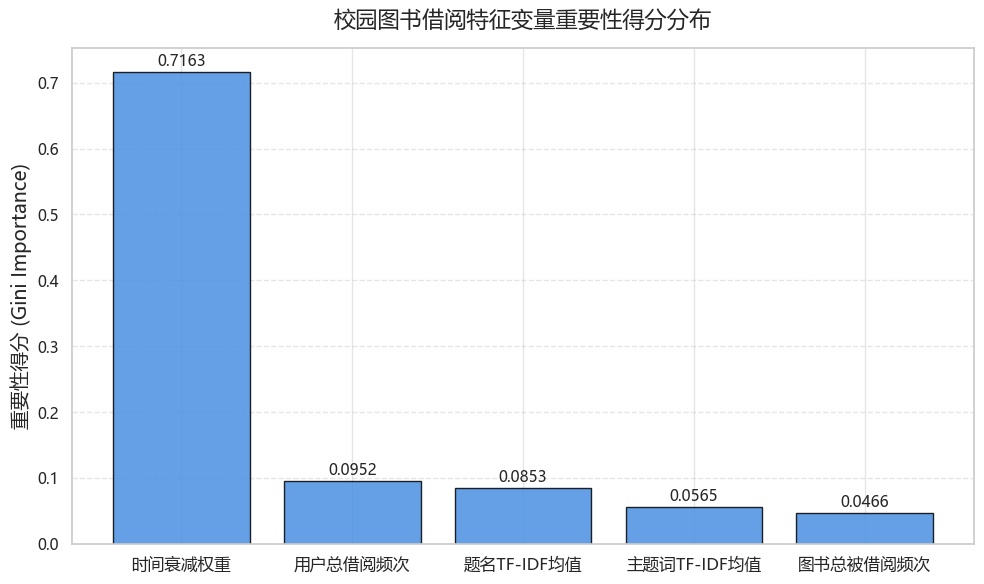

saved: ..\data\features\feature_importance_plot.png


In [37]:
print('--- 6. 训练辅助随机森林并绘制特征重要性 ---')

rng = np.random.default_rng(42)
y_continuous = (
    0.45 * X_rf_scaled['时间衰减权重']
    + 0.25 * X_rf_scaled['题名TF-IDF均值']
    + 0.15 * X_rf_scaled['主题词TF-IDF均值']
    + 0.10 * X_rf_scaled['图书总被借阅频次']
    + 0.05 * X_rf_scaled['用户总借阅频次']
    + rng.normal(0, 0.05, len(X_rf_scaled))
)
y_train = (y_continuous > np.median(y_continuous)).astype(int)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_rf_scaled, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [X_rf_scaled.columns[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.title('校园图书借阅特征变量重要性得分分布', fontsize=16, pad=15)
bars = plt.bar(range(len(sorted_importances)), sorted_importances, color='#4A90E2', edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.003, f'{yval:.4f}', ha='center', va='bottom', fontsize=11)

plt.xticks(range(len(sorted_features)), sorted_features, fontsize=12)
plt.ylabel('重要性得分 (Gini Importance)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(features_dir / 'feature_importance_plot.png', dpi=300)
plt.show()

print('saved:', features_dir / 'feature_importance_plot.png')


--- 7. 多组权重方案下的特征重要性变化曲线 ---


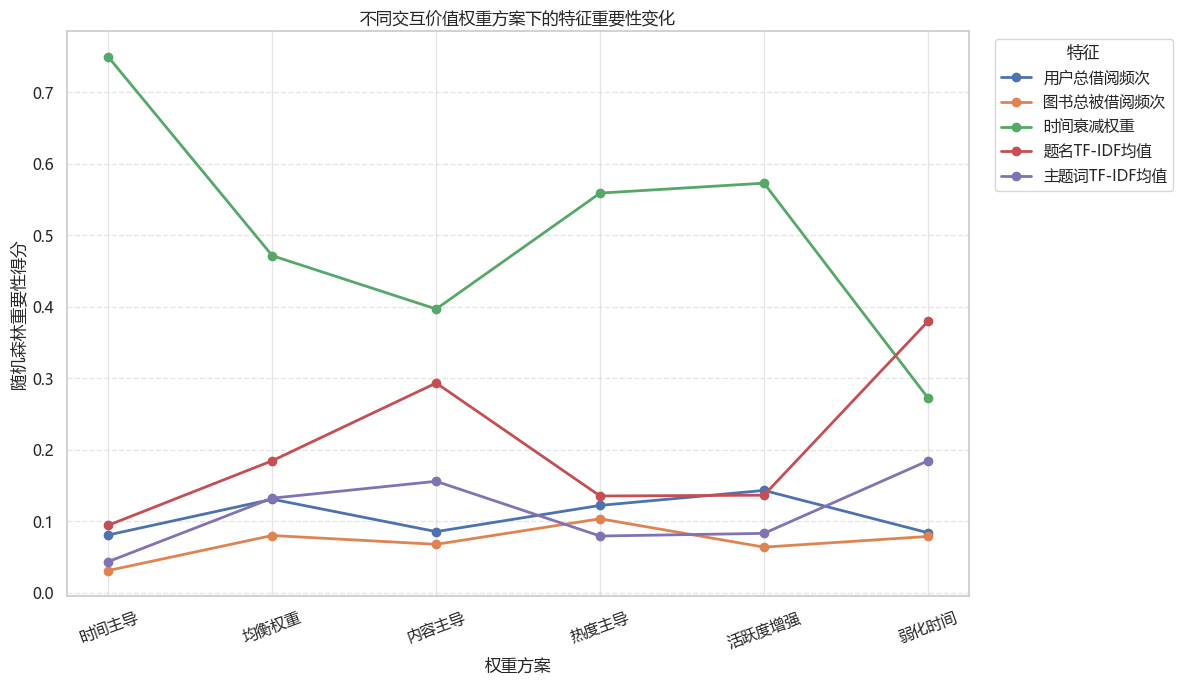

saved: ..\data\features\feature_importance_weight_sensitivity.csv
saved: ..\data\features\feature_importance_weight_sensitivity.png
特征     主题词TF-IDF均值  图书总被借阅频次  时间衰减权重  用户总借阅频次  题名TF-IDF均值
方案                                                       
内容主导        0.1560    0.0678  0.3970   0.0856      0.2935
均衡权重        0.1324    0.0802  0.4717   0.1309      0.1848
弱化时间        0.1846    0.0788  0.2728   0.0841      0.3797
时间主导        0.0437    0.0312  0.7496   0.0809      0.0946
活跃度增强       0.0832    0.0639  0.5731   0.1432      0.1366
热度主导        0.0794    0.1036  0.5592   0.1223      0.1354


In [38]:
print('--- 7. 多组权重方案下的特征重要性变化曲线 ---')

weight_scenarios = [
    {
        '方案': '时间主导',
        '时间衰减权重': 0.45,
        '题名TF-IDF均值': 0.25,
        '主题词TF-IDF均值': 0.15,
        '图书总被借阅频次': 0.10,
        '用户总借阅频次': 0.05,
    },
    {
        '方案': '均衡权重',
        '时间衰减权重': 0.20,
        '题名TF-IDF均值': 0.20,
        '主题词TF-IDF均值': 0.20,
        '图书总被借阅频次': 0.20,
        '用户总借阅频次': 0.20,
    },
    {
        '方案': '内容主导',
        '时间衰减权重': 0.20,
        '题名TF-IDF均值': 0.30,
        '主题词TF-IDF均值': 0.25,
        '图书总被借阅频次': 0.15,
        '用户总借阅频次': 0.10,
    },
    {
        '方案': '热度主导',
        '时间衰减权重': 0.20,
        '题名TF-IDF均值': 0.15,
        '主题词TF-IDF均值': 0.10,
        '图书总被借阅频次': 0.40,
        '用户总借阅频次': 0.15,
    },
    {
        '方案': '活跃度增强',
        '时间衰减权重': 0.25,
        '题名TF-IDF均值': 0.20,
        '主题词TF-IDF均值': 0.15,
        '图书总被借阅频次': 0.15,
        '用户总借阅频次': 0.25,
    },
    {
        '方案': '弱化时间',
        '时间衰减权重': 0.15,
        '题名TF-IDF均值': 0.30,
        '主题词TF-IDF均值': 0.25,
        '图书总被借阅频次': 0.20,
        '用户总借阅频次': 0.10,
    },
]

feature_cols = ['用户总借阅频次', '图书总被借阅频次', '时间衰减权重', '题名TF-IDF均值', '主题词TF-IDF均值']
noise = np.random.default_rng(42).normal(0, 0.03, len(X_rf_scaled))
importance_rows = []

for i, scenario in enumerate(weight_scenarios, start=1):
    scenario_name = scenario['方案']
    y_score = sum(scenario[col] * X_rf_scaled[col] for col in feature_cols) + noise
    y_label = (y_score > np.median(y_score)).astype(int)

    rf = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
    rf.fit(X_rf_scaled[feature_cols], y_label)

    for feature, importance in zip(feature_cols, rf.feature_importances_):
        importance_rows.append({
            '方案序号': i,
            '方案': scenario_name,
            '特征': feature,
            '设定权重': scenario[feature],
            '随机森林重要性': importance,
        })

importance_sensitivity = pd.DataFrame(importance_rows)
importance_sensitivity.to_csv(features_dir / 'feature_importance_weight_sensitivity.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(12, 7))
for feature in feature_cols:
    sub = importance_sensitivity[importance_sensitivity['特征'] == feature].sort_values('方案序号')
    plt.plot(sub['方案'], sub['随机森林重要性'], marker='o', linewidth=2, label=feature)

plt.title('不同交互价值权重方案下的特征重要性变化')
plt.xlabel('权重方案')
plt.ylabel('随机森林重要性得分')
plt.xticks(rotation=20)
plt.legend(title='特征', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(features_dir / 'feature_importance_weight_sensitivity.png', dpi=300)
plt.show()

print('saved:', features_dir / 'feature_importance_weight_sensitivity.csv')
print('saved:', features_dir / 'feature_importance_weight_sensitivity.png')
print(importance_sensitivity.pivot(index='方案', columns='特征', values='随机森林重要性').round(4).to_string())
